# SmartRoad - Traffic Accident Analytics

Computational Analytics Assignment 2. This notebook performs acquisition, cleaning, EDA, visualization, feature engineering, classification, cross-validation, evaluation and hotspot clustering.

**Academic data note:** the project includes a synthetic DEMO dataset for local validation. For submission, download the official 2025 DfT collisions CSV using `download_data.py`.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from analytics import load_data, preprocess, clean_numeric_ranges, build_model, permutation_importance_table, fit_cluster, make_charts


In [2]:
DATA = PROJECT_ROOT / 'data' / 'road_collisions_2025.csv'
if not DATA.exists():
    DATA = PROJECT_ROOT / 'data' / 'demo_accidents.csv'
print('Using:', DATA)
raw = load_data(DATA)
print(raw.shape)
display(raw.head())


Using: /mnt/data/SmartRoad_Traffic_Accident_Analytics/data/demo_accidents.csv
(6040, 18)


,accident_index,latitude,longitude,accident_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,road_type,speed_limit,junction_detail,light_conditions,weather_conditions,road_surface_conditions,urban_or_rural_area,first_road_class,police_force
0,DEMO100000,52.652944,-1.861344,2,2,2,15/08/2025,5,12:43,3,60.0,8,6,2.0,1.0,1,3,1
1,DEMO100001,56.085475,-3.277754,2,2,3,30/10/2025,4,10:52,3,40.0,1,4,1.0,2.0,1,5,5
2,DEMO100002,53.100369,-1.040379,2,3,4,22/08/2025,5,01:08,12,30.0,3,1,1.0,6.0,1,4,42
3,DEMO100003,53.588204,-3.356493,3,2,3,05/08/2025,2,02:14,2,50.0,0,1,9.0,1.0,1,4,7
4,DEMO100004,53.715960,-3.364026,3,1,2,20/06/2025,5,14:02,2,70.0,3,1,1.0,3.0,1,1,29


## 1. Data quality and preprocessing

In [3]:
print('Duplicates:', raw.duplicated().sum())
print('Missing cells:', int(raw.isna().sum().sum()))

df = clean_numeric_ranges(preprocess(raw))
print('Rows after duplicate removal:', len(df))
display(df[['date','hour','month','day_name','weekend','night','rush_hour','severity_label','high_severity']].head())

Duplicates: 40
Missing cells: 499
Rows after duplicate removal: 6000


,date,hour,month,day_name,weekend,night,rush_hour,severity_label,high_severity
0,2025-08-15,12,8,Friday,0,0,0,Serious,1
1,2025-10-30,10,10,Thursday,0,0,0,Serious,1
2,2025-08-22,1,8,Friday,0,1,0,Serious,1
3,2025-08-05,2,8,Tuesday,0,1,0,Slight,0
4,2025-06-20,14,6,Friday,0,0,0,Slight,0


## 2. Exploratory analysis

In [4]:
display(df.describe(include='all').T.head(25))
display(df['severity_label'].value_counts().rename_axis('severity').to_frame('count'))

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
accident_index,6000,6000,DEMO100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,5940.0,NaN,NaN,NaN,53.374505,50.893333,52.275303,53.351325,54.260632,56.441267,1.476498
longitude,5940.0,NaN,NaN,NaN,-2.566767,-6.743069,-3.242762,-2.416451,-1.532071,0.767513,1.493559
accident_severity,6000.0,NaN,NaN,NaN,2.614833,1.0,2.0,3.0,3.0,3.0,0.557553
number_of_vehicles,6000.0,NaN,NaN,NaN,2.701833,1.0,2.0,3.0,3.25,8.0,1.298927
number_of_casualties,6000.0,NaN,NaN,NaN,3.498,1.0,2.0,3.0,4.0,10.0,1.573131
date,6000,NaN,NaN,NaN,2025-06-30 12:59:45.600000256,2025-01-01 00:00:00,2025-04-02 00:00:00,2025-07-01 00:00:00,2025-09-28 00:00:00,2025-12-31 00:00:00,NaN
day_of_week,6000.0,NaN,NaN,NaN,3.985667,1.0,2.0,4.0,6.0,7.0,2.006024
time,6000,1422,00:31,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_type,6000.0,NaN,NaN,NaN,5.717667,1.0,3.0,6.0,9.0,12.0,3.293948


,count
severity,
Slight,3911
Serious,1867
Fatal,222


## 3. Required visualizations (minimum 5 chart types)

In [5]:
chart_names = make_charts(df, str(PROJECT_ROOT / 'outputs' / 'notebook_charts'))
chart_names


['01_accidents_by_hour.png',
 '02_severity_distribution.png',
 '03_speed_limit_histogram.png',
 '04_weekday_hour_heatmap.png',
 '05_speed_by_severity_boxplot.png',
 '06_accident_scatter_map.png']

The generated chart set includes a line chart, bar chart, histogram, heatmap, boxplot and geographic scatter plot.

## 4. Predictive modeling

In [6]:
rf, X_test, y_test, pred, metrics, features = build_model(df, 'Random Forest')
print(metrics)
print('Features:', features)

{'accuracy': 0.63, 'precision': 0.44396551724137934, 'recall': 0.24641148325358853, 'f1': 0.3169230769230769, 'n_train': 4800, 'n_test': 1200, 'positive_rate': 0.3481666666666667, 'cv_f1_mean': 0.31426868286086995, 'cv_f1_std': 0.01835337255487835}
Features: ['hour', 'month', 'weekend', 'night', 'rush_hour', 'speed_limit', 'number_of_vehicles', 'multi_vehicle', 'road_type', 'junction_detail', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'first_road_class']


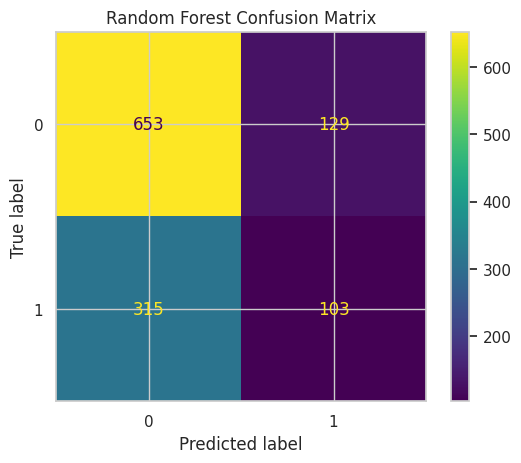

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test,pred)
plt.title('Random Forest Confusion Matrix')
plt.show()

In [8]:
imp = permutation_importance_table(rf, X_test, y_test)
display(imp.head(15))

,feature,importance_mean,importance_std
10,light_conditions,0.029363,0.008022
3,night,0.029356,0.013031
5,speed_limit,0.022390,0.009119
0,hour,0.020050,0.013749
14,first_road_class,0.017992,0.010130
11,weather_conditions,0.009422,0.008901
6,number_of_vehicles,0.008468,0.011372
7,multi_vehicle,0.008390,0.006913
9,junction_detail,0.007921,0.011560
13,urban_or_rural_area,0.007257,0.006878


## 5. Hotspot clustering

In [9]:
cluster_points, cluster_summary = fit_cluster(df, 8)
display(cluster_summary.sort_values('high_severity_rate', ascending=False))

,cluster,accidents,high_severity_rate,latitude,longitude
7,7,1022,0.365949,52.686761,-1.555918
3,3,453,0.362031,51.494086,-0.114975
6,6,503,0.361829,55.945435,-3.198093
4,4,519,0.348748,54.588773,-5.931245
5,5,815,0.344785,53.429781,-2.774498
0,0,1168,0.343322,53.581613,-1.568131
2,2,938,0.333689,51.473830,-2.882246
1,1,462,0.324675,55.874823,-4.265246


## 6. Conclusions

Use the output metrics, charts and hotspot summary generated from the official dataset for the final submission. The included demo run is only for software validation and should not be presented as official accident statistics.